In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay

In [47]:
class MedianImputerTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns):
        self.columns = columns;
        self.learned_median = {}
        
        
    def fit(self, X, y=None):
        
        for col in self.columns:
            self.learned_median[col] = X[col].median()
            
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        for col in self.columns:
            X_copy[col] = X_copy[col].fillna(self.learned_median[col])
            
        return X_copy

In [64]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

X = df.drop(['id','stroke'], axis=1)
y = df['stroke']

print(X.info())
print((y==0).sum())
print((y==1).sum())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 399.3 KB
None
4861
249


In [53]:
# Preprocess Data

preprocess_median = ColumnTransformer(
    transformers = [
        ('median_imputer', MedianImputerTransformer(columns=['bmi']), ['bmi']),
        ('hot_encoder', OneHotEncoder(sparse_output=False), ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])
    ],
    remainder='passthrough'
)

In [54]:
# Model's Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocess_median),
    ('standardize', StandardScaler()),
    ('naive_bayes', GaussianNB())
])


In [ ]:
# Train model

pipeline.fit(X_test, y_test)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('standardize', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['gender','age','hypertension',...,'avg_glucose_level','bmi', 'smoking_status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('median_imputer', ...), ('hot_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

In [69]:
# PREDICTIONS

predictions = pipeline.predict(X_test)
print(predictions)


proba = pipeline.predict_proba(X_test)[:, 1]
print(proba)

[1 1 0 ... 1 0 1]
[9.99846038e-01 9.99325474e-01 2.75183049e-01 ... 9.96101864e-01
 1.95079267e-11 9.99905233e-01]


In [62]:
# REPORT

print(classification_report(y_test, predictions))

print(f"\nCONFUSION MATRIX\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

           0       1.00      0.30      0.46       972
           1       0.07      0.98      0.13        50

    accuracy                           0.34      1022
   macro avg       0.53      0.64      0.30      1022
weighted avg       0.95      0.34      0.45      1022


CONFUSION MATRIX
[[294 678]
 [  1  49]]


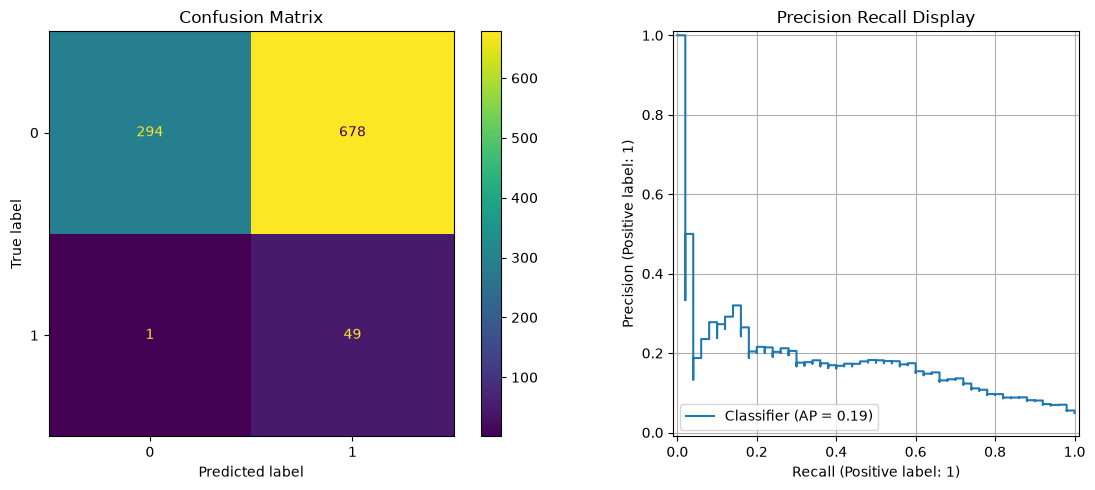

In [71]:
# VISUALIZATION

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix")

PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].grid(True)
axes[1].set_title("Precision Recall Display")

plt.tight_layout()
plt.show()